### Проект Сегментация клиентов по признакам (AN-1837)

#### Описание задачи

Необходимо разделить пользователей на группы по совокупности признаков:

- кол-во измений в кампании
- какие параметры чаще меняются
- общий спенд на пользователя
- частота пополнений

Под параметрами здесь подразумевается работа пользователя с настройками/таргетами РК.

Так как таких настроек очень много, мы разделили их на смысловые группы.

Группы следующие :

1. Характеристики аудитории **"audience"**
(страна, регион, город, язык, ОС, браузер, IP range, device type, categories, carriers)
2. Таргет на источники __"sources"__
(WL / BL по сайтам, спотам)
3. Ограничение объемов **"limits"** (лимиты все)
4. Настройки качества **"quality"** (traffic quality(traffic type), ip2location, ipv6)
5. Уникальность трафика **"unique"** (использование таргета на уников)
6. Работа с ценой **"price"** (Price, autoadjust, microbidding)

#### Загрузка данных

In [335]:
import os
import pandas as pd
import numpy as np
import sqlalchemy as sql
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import re
import math
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
from scipy.stats import gaussian_kde

In [84]:
db_config = {
'host': 'dbro.clickadilla.com',
'port' : 3306,
'db' : 'clickadilla_db',
'user' : os.getenv('MYSQL_USER'),
'pass' : os.getenv('MYSQL_PASSWORD'),
}
 
# connection_string = "mysql+pymysql://<dbuser>:<pwd>@<server_ip>/<db_instance>"
connection_string = 'mysql+pymysql://{}:{}@{}/{}'.format(
    db_config['user'],
    db_config['pass'],
    db_config['host'],
    db_config['db'],
)

In [85]:
engine = create_engine(connection_string)

In [86]:
def select(sql):
  return pd.read_sql(sql, con=engine)

In [1]:
sql = '''
WITH base AS (
  SELECT
    a.user_id,
    a.auditable_id AS campaign_id,
    a.old_values,
    a.new_values
  FROM audits a
  LEFT JOIN campaigns c ON c.id = a.auditable_id
  WHERE a.created_at BETWEEN '2025-06-25' AND '2025-09-11'
    AND a.auditable_type LIKE '%%campaign'
    AND a.user_type LIKE '%%user'
    AND a.event <> 'deleted'
    AND a.user_agent <> 'Symfony'
    AND a.ip_address NOT IN ('52.18.41.245','54.194.2.114','99.80.49.98','109.206.170.203')
    AND c.sale_type = 'regular sale'
),

bids AS (
  SELECT
    u.id        AS user_id,
    c.id        AS campaign_id,
    COUNT(*)    AS g2_price_from_bids
  FROM campaign_site_biddings b
  JOIN campaigns c ON c.id = b.campaign_id
  JOIN users    u ON u.id = c.user_id
  WHERE b.created_at BETWEEN '2025-06-25' AND '2025-09-11'
  GROUP BY u.id, c.id
),

flags AS (
  SELECT
    user_id,
    campaign_id,

    (
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.country_target')          OR JSON_CONTAINS_PATH(new_values,'one','$.targets.country_target')) +
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.category_group_target')   OR JSON_CONTAINS_PATH(new_values,'one','$.targets.category_group_target')) +
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.region_target')           OR JSON_CONTAINS_PATH(new_values,'one','$.targets.region_target')) +
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.browser_target')          OR JSON_CONTAINS_PATH(new_values,'one','$.targets.browser_target')) +
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.city_target')             OR JSON_CONTAINS_PATH(new_values,'one','$.targets.city_target')) +
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.language_target')         OR JSON_CONTAINS_PATH(new_values,'one','$.targets.language_target')) +
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.device_model_target')     OR JSON_CONTAINS_PATH(new_values,'one','$.targets.device_model_target')) +
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.traffic_type_target')     OR JSON_CONTAINS_PATH(new_values,'one','$.targets.traffic_type_target')) +
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.device_vendor_target')    OR JSON_CONTAINS_PATH(new_values,'one','$.targets.device_vendor_target')) +
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.ip_ranges_target')        OR JSON_CONTAINS_PATH(new_values,'one','$.targets.ip_ranges_target')) +
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.operating_system_target') OR JSON_CONTAINS_PATH(new_values,'one','$.targets.operating_system_target')) +
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.category_target')         OR JSON_CONTAINS_PATH(new_values,'one','$.targets.category_target')) +
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.carrier_target')          OR JSON_CONTAINS_PATH(new_values,'one','$.targets.carrier_target'))
    ) AS g1_audiences,

    (
      (
        JSON_CONTAINS_PATH(old_values,'one','$.price') AND
        JSON_CONTAINS_PATH(new_values,'one','$.price') AND
        NOT (
          CAST(JSON_UNQUOTE(JSON_EXTRACT(old_values,'$.price')) AS SIGNED)
          <=>
          CAST(JSON_UNQUOTE(JSON_EXTRACT(new_values,'$.price')) AS SIGNED)
        )
      )
      +
      (
        JSON_CONTAINS_PATH(old_values,'one','$.enable_price_auto_adjust') AND
        JSON_CONTAINS_PATH(new_values,'one','$.enable_price_auto_adjust') AND
        NOT (
          CAST(JSON_UNQUOTE(JSON_EXTRACT(old_values,'$.enable_price_auto_adjust')) AS UNSIGNED)
          <=>
          CAST(JSON_UNQUOTE(JSON_EXTRACT(new_values,'$.enable_price_auto_adjust')) AS UNSIGNED)
        )
      )
    ) AS g2_price_from_audits,

    (
      (JSON_VALUE(old_values,'$.calendar_limits')         IS NOT NULL OR JSON_VALUE(new_values,'$.calendar_limits')         IS NOT NULL) +
      (JSON_VALUE(old_values,'$.daily_click_limit')       IS NOT NULL OR JSON_VALUE(new_values,'$.daily_click_limit')       IS NOT NULL) +
      (JSON_VALUE(old_values,'$.daily_money_limit')       IS NOT NULL OR JSON_VALUE(new_values,'$.daily_money_limit')       IS NOT NULL) +
      (JSON_VALUE(old_values,'$.total_click_limit')       IS NOT NULL OR JSON_VALUE(new_values,'$.total_click_limit')       IS NOT NULL) +
      (JSON_VALUE(old_values,'$.total_money_limit')       IS NOT NULL OR JSON_VALUE(new_values,'$.total_money_limit')       IS NOT NULL) +
      (JSON_VALUE(old_values,'$.hourly_click_limit')      IS NOT NULL OR JSON_VALUE(new_values,'$.hourly_click_limit')      IS NOT NULL) +
      (JSON_VALUE(old_values,'$.hourly_money_limit')      IS NOT NULL OR JSON_VALUE(new_values,'$.hourly_money_limit')      IS NOT NULL) +
      (JSON_VALUE(old_values,'$.daily_impression_limit')  IS NOT NULL OR JSON_VALUE(new_values,'$.daily_impression_limit')  IS NOT NULL) +
      (JSON_VALUE(old_values,'$.total_impression_limit')  IS NOT NULL OR JSON_VALUE(new_values,'$.total_impression_limit')  IS NOT NULL) +
      (JSON_VALUE(old_values,'$.hourly_impression_limit') IS NOT NULL OR JSON_VALUE(new_values,'$.hourly_impression_limit') IS NOT NULL)
    ) AS g3_limits,

    (
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.site_target') OR JSON_CONTAINS_PATH(new_values,'one','$.targets.site_target')) +
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.spot_target') OR JSON_CONTAINS_PATH(new_values,'one','$.targets.spot_target'))
    ) AS g4_sources,

    (
      JSON_CONTAINS_PATH(old_values,'one','$.targets.uniques_target') OR
      JSON_CONTAINS_PATH(new_values,'one','$.targets.uniques_target')
    ) AS g5_uniqueness,

    (
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.campaign_traffic_platform_target') OR JSON_CONTAINS_PATH(new_values,'one','$.targets.campaign_traffic_platform_target')) +
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.ip2_location_type_target')        OR JSON_CONTAINS_PATH(new_values,'one','$.targets.ip2_location_type_target')) +
      (JSON_CONTAINS_PATH(old_values,'one','$.targets.ipv6_target')                     OR JSON_CONTAINS_PATH(new_values,'one','$.targets.ipv6_target'))
    ) AS g6_quality
  FROM base
),

per_campaign_from_audits AS (
  SELECT
    user_id,
    campaign_id,
    SUM(g1_audiences)         AS g1_changes,
    SUM(g2_price_from_audits) AS g2_changes_from_audits,
    SUM(g3_limits)            AS g3_changes,
    SUM(g4_sources)           AS g4_changes,
    SUM(g5_uniqueness)        AS g5_changes,
    SUM(g6_quality)           AS g6_changes
  FROM flags
  GROUP BY user_id, campaign_id
),

per_campaign AS (
  SELECT
    p.user_id,
    p.campaign_id,
    p.g1_changes,
    (p.g2_changes_from_audits + IFNULL(b.g2_price_from_bids,0)) AS g2_changes,
    p.g3_changes, p.g4_changes, p.g5_changes, p.g6_changes
  FROM per_campaign_from_audits p
  LEFT JOIN bids b ON b.user_id = p.user_id AND b.campaign_id = p.campaign_id

  UNION ALL
  SELECT
    b.user_id,
    b.campaign_id,
    0 AS g1_changes,
    b.g2_price_from_bids AS g2_changes,
    0 AS g3_changes, 0 AS g4_changes, 0 AS g5_changes, 0 AS g6_changes
  FROM bids b
  LEFT JOIN per_campaign_from_audits p
    ON p.user_id = b.user_id AND p.campaign_id = b.campaign_id
  WHERE p.user_id IS NULL
),

campaigns_with_changes AS (
  SELECT user_id, campaign_id
  FROM per_campaign
  WHERE (g1_changes + g2_changes + g3_changes + g4_changes + g5_changes + g6_changes) > 0
),

filtered_per_campaign AS (
  SELECT p.*
  FROM per_campaign p
  JOIN campaigns_with_changes cw USING (user_id, campaign_id)
),

campaigns_cnt_per_user AS (
  SELECT user_id, COUNT(DISTINCT campaign_id) AS campaigns_cnt
  FROM campaigns_with_changes
  GROUP BY user_id
),

spend AS (
SELECT p.user_id,
round(SUM(p.amount/10000), 1) AS spend
FROM payments p
WHERE p.`type` = 'campaign'
AND p.created_at BETWEEN '2025-06-25' AND '2025-09-11'
GROUP BY p.user_id),

payments AS (
SELECT p.user_id,
COUNT(*) AS payments
FROM payments p
WHERE p.`type` IN ('invoiced', 'fresh_books')
AND p.created_at BETWEEN '2025-06-25' AND '2025-09-11'
GROUP BY p.user_id),

spend_days AS (
SELECT t.user_id,
SUM(t.spend_days) sum_days,
SUM(t.spend_days)/COUNT(DISTINCT t.campaign_id) AS per_campaign
FROM (
SELECT u.id AS user_id,
cs.campaign_id,
COUNT(DISTINCT DATE(cs.date)) AS spend_days
FROM campaign_statistics cs
LEFT JOIN campaigns c ON cs.campaign_id = c.id
LEFT JOIN users u ON c.user_id = u.id
WHERE DATE(cs.date) BETWEEN '2025-06-25' AND '2025-09-11'
GROUP BY cs.campaign_id) AS t
GROUP BY t.user_id)

SELECT
  p.user_id,
  u.email,
  COALESCE(spend.spend, 0) AS spend,
  COALESCE(payments.payments, 0) AS payments,
  c.campaigns_cnt AS campaigns,
  ROUND(SUM(p.g1_changes)/c.campaigns_cnt, 6) AS audiences,
  ROUND(SUM(p.g2_changes)/c.campaigns_cnt, 6) AS price,
  ROUND(SUM(p.g3_changes)/c.campaigns_cnt, 6) AS limits,
  ROUND(SUM(p.g4_changes)/c.campaigns_cnt, 6) AS sources,
  ROUND(SUM(p.g5_changes)/c.campaigns_cnt, 6) AS uniques,
  ROUND(SUM(p.g6_changes)/c.campaigns_cnt, 6) AS quality,
SUM(
    p.g1_changes + p.g2_changes + p.g3_changes +
    p.g4_changes + p.g5_changes + p.g6_changes
  ) AS total_changes,
  ROUND(
    SUM(
      p.g1_changes + p.g2_changes + p.g3_changes +
      p.g4_changes + p.g5_changes + p.g6_changes
    ) / c.campaigns_cnt, 6
  ) AS changes_per_campaign,
  COALESCE(sd.sum_days, 0) AS spend_days,
  COALESCE(sd.per_campaign,0) AS spend_days_per_campaign
FROM filtered_per_campaign p
JOIN campaigns_cnt_per_user c USING (user_id)
JOIN users u ON u.id = p.user_id
LEFT JOIN spend ON p.user_id = spend.user_id
LEFT JOIN payments ON p.user_id = payments.user_id
LEFT JOIN spend_days sd ON p.user_id = sd.user_id
WHERE p.user_id NOT IN (
  SELECT id FROM users
  WHERE email LIKE '%%onlinesup%%' OR email LIKE '%%tubecorp%%'
)
AND p.user_id NOT IN (SELECT DISTINCT user_id
FROM networks)
GROUP BY p.user_id, u.email, c.campaigns_cnt
'''

In [91]:
df = select(sql)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1185 entries, 0 to 1184
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  1185 non-null   int64  
 1   email                    1185 non-null   object 
 2   spend                    1185 non-null   float64
 3   payments                 1185 non-null   int64  
 4   campaigns                1185 non-null   int64  
 5   audiences                1185 non-null   float64
 6   price                    1185 non-null   float64
 7   limits                   1185 non-null   float64
 8   sources                  1185 non-null   float64
 9   uniques                  1185 non-null   float64
 10  quality                  1185 non-null   float64
 11  total_changes            1185 non-null   float64
 12  changes_per_campaign     1185 non-null   float64
 13  spend_days               1185 non-null   float64
 14  spend_days_per_campaign 

In [93]:
df.head()

,user_id,email,spend,payments,campaigns,audiences,price,limits,sources,uniques,quality,total_changes,changes_per_campaign,spend_days,spend_days_per_campaign
0,7569,dg99gz@gmail.com,472.7,3,8,0.25,3.2500,0.0000,0.2500,0.125,0.0,31.0,3.8750,411.0,25.6875
1,16721,leo@stripchat.com,106759.4,3,7,0.00,0.0000,1.2857,0.0000,0.000,0.0,9.0,1.2857,1868.0,43.4419
2,23385,jefrey2dk@gmail.com,1119.8,7,12,1.50,1.8333,0.0000,0.0833,0.000,1.0,53.0,4.4167,31.0,2.5833
3,15132,o.borkovskii@evadav.com,6006.8,1,15,1.80,0.4667,0.0000,1.5333,0.000,0.0,57.0,3.8000,2058.0,55.6216
4,25389,xprimus2@yahoo.com,0.0,0,1,0.00,2.0000,0.0000,1.0000,0.000,0.0,3.0,3.0000,0.0,0.0000


### EDA

#### Описательная статистика

In [94]:
df.describe()

,user_id,spend,payments,campaigns,audiences,price,limits,sources,uniques,quality,total_changes,changes_per_campaign,spend_days,spend_days_per_campaign
count,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000
mean,143509.451477,587.139156,2.108861,33.459916,3.631354,1.963055,1.095401,1.302695,0.404626,0.235745,224.773840,8.632876,150.917300,7.861260
std,66668.597420,3539.132942,6.514858,534.689661,2.610771,9.993663,2.065404,15.974472,0.641984,0.469581,2760.214896,24.744001,969.193159,13.399327
min,49.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,90807.000000,2.500000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,1.000000,1.000000
50%,181147.000000,49.000000,1.000000,2.000000,3.000000,0.833300,0.750000,0.000000,0.000000,0.000000,17.000000,6.000000,9.000000,2.500000
75%,195340.000000,197.000000,1.000000,6.000000,5.000000,2.000000,1.500000,0.500000,0.888900,0.250000,48.000000,9.333300,49.000000,8.000000
max,200439.000000,106759.400000,90.000000,15953.000000,22.500000,286.000000,39.000000,440.454500,10.750000,3.000000,79844.000000,730.136400,20310.000000,79.000000


<font size="3"> Пока сделаем общее описание данных, углубимся в распределение после кластеризации(сегментации)

У нас 1185 пользователя в анализе за период 25-06/10-09

Медианный спенд - ~50$ (адекватно текущей ситуации), есть пользователи без спенда, есть крупные пользователи.

Ситуция с пополнениями схожа, есть пустые юзеры (без спенда/пополнений), есть выбросы (макс - 90 пополнений). <br>Медианное кол-во пополнений - 1 раз

Кампании - минимум 1 с редактированиями, медиана - 2 кампании, максимум - 15953 (Зинченко)

Медианное кол-во изменений для аудиторий - 3 раза, цена и лимиты - около 1 раза, сурсы, уники и споты - <1 (здесь немного детализируем далее)

Медианная сумма изменений на юзера - 17 раз, в среднем на одну кампанию - 6

Медиана дней спенда - 9, на 1 кампанию - 2,5 дня

**Так как ключевая задача - сегментировать клиентов, на данный момент не будем удалять никаких выбросов, они важны для разграничения сегментов**

Пока лишь обозначим границы аномалий

#### Распределения признаков

Детальнее рассмотрим признаки, характеризующие работу с настройками/таргетами кампании

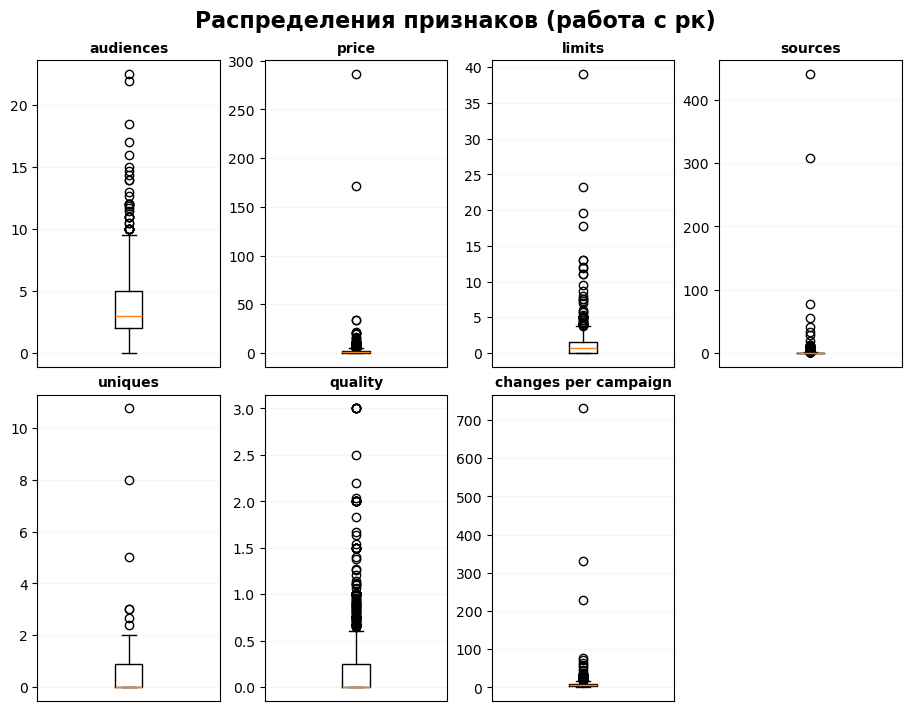

In [95]:
exclude = {'user_id', 'email', 'spend', 'payments', 'campaigns', 'spend_days', 'spend_days_per_campaign',
          'total_changes'}
ncols = 4                               # сколько графиков в строке
figsize_per_plot = (4, 3.5)             # размер одного подграфика (ширина, высота) в дюймах
show_means = True                       # показывать среднее в boxplot

# (опция) функция чистки названий: убрать все 'g<цифры>' и '_' (иначе вернём исходное имя)
def clean_label(s: str) -> str:
    s = re.sub(r"g\d+_?", " ", s)       # g1, g23, g7_ и т.п.
    return s.replace("_", " ")           # или .replace("_", " ") если хотите пробелы

# ---- выбор колонок
num_cols = df.select_dtypes(include="number").columns
cols = [c for c in num_cols if c not in exclude]
k = len(cols)
if k == 0:
    raise ValueError("Нет числовых колонок (кроме 'user_id' и 'email') для построения boxplot.")

# ---- фигура и оси
nrows = math.ceil(k / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(9, 7), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

# ---- отрисовка
for ax, col in zip(axes, cols):
    data = df[col].dropna().values
    ax.boxplot(
        data,
        vert=True,
        showmeans=False,
        meanline=False
    )
    ax.set_title(clean_label(col), fontsize=10, fontweight='bold', pad=6)
    ax.set_xticks([])                  # ось X тут не информативна
    ax.grid(axis='y', linestyle=':', alpha=0.3)

# скрыть пустые ячейки сетки
for ax in axes[k:]:
    ax.set_visible(False)

fig.suptitle("Распределения признаков (работа с рк)", fontsize=16, fontweight='bold')
plt.show()


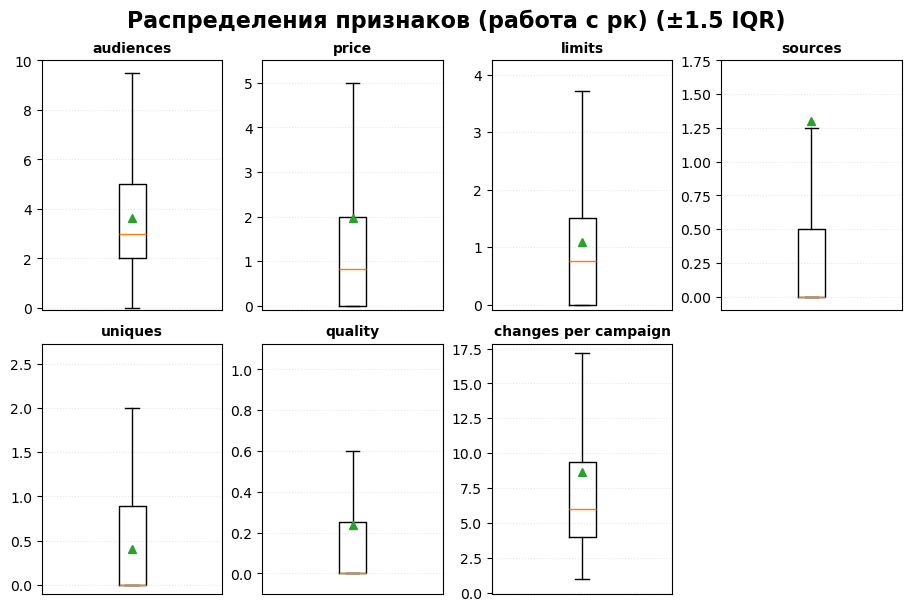

In [97]:
exclude =  {'user_id', 'email', 'spend', 'payments', 'campaigns', 'spend_days', 'spend_days_per_campaign',
           'total_changes'}
ncols = 4                       # сколько графиков в строке
figsize_per_plot = (4, 3.5)     # размер одного подграфика (дюймы)
show_means = True               # показывать среднее

# очистка названий: убрать все 'g<числа>' и '_'
def clean_label(s: str) -> str:
    s = re.sub(r"g\d+_?", " ", s)   # g1, g23, g7_ и т.п.
    return s.replace("_", " ")      # или .replace("_", " ") — если хотите пробелы

# границы по Тьюки (с защитой для вырожденных случаев)
def tukey_limits(x: np.ndarray):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return None
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    if not np.isfinite(iqr) or iqr == 0:
        if x.size > 1:
            lo, hi = np.percentile(x, [1, 99])
            if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
                lo, hi = x.min(), x.max()
        else:
            m = float(x[0]); lo, hi = m-1, m+1
    else:
        lo = q1 - 1.5 * iqr
        hi = q3 + 1.5 * iqr
    if lo == hi:
        pad = 0.5 if lo == 0 else 0.05 * abs(lo)
        lo -= pad; hi += pad
    return float(lo), float(hi)

# --- выбор колонок
num_cols = df.select_dtypes(include="number").columns
cols = [c for c in num_cols if c not in exclude]
k = len(cols)
if k == 0:
    raise ValueError("Нет числовых колонок (кроме 'user_id' и 'email') для boxplot.")

# --- фигура и оси
nrows = math.ceil(k / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(9, 6), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

# --- отрисовка
for ax, col in zip(axes, cols):
    x = df[col].dropna().astype(float).values
    if x.size == 0:
        ax.set_visible(False); continue

    lims = tukey_limits(x)
    if lims is None:
        ax.set_visible(False); continue
    ylo_tukey, yhi = lims

    # нижнюю границу фиксируем на -0.01, верхнюю — как рассчитали по Тьюки
    ylo = -0.1
    if yhi <= ylo:              # страховка на случай вырожденного диапазона
        yhi = ylo + 0.01

    ax.boxplot(
        x,
        vert=True,
        whis=1.5,          # усы = ±1.5 IQR от квартилей
        showfliers=False,  # выбросы не рисуем
        showmeans=show_means,
        meanline=False
    )
    ax.set_ylim(ylo, yhi + 0.5)
    ax.set_title(clean_label(col), fontsize=10, fontweight='bold', pad=6)
    ax.set_xticks([])
    ax.grid(axis='y', linestyle=':', alpha=0.3)

# скрыть пустые ячейки сетки
for ax in axes[k:]:
    ax.set_visible(False)

fig.suptitle("Распределения признаков (работа с рк) (±1.5 IQR)", fontsize=16, fontweight='bold')
plt.show()


Видим выбросы, отметим характерные значения для каждого признака (непосредственно для настроек/таргетов) :
- **audience :** max >20 изменений на кампанию, медиана - 3, среднее (зелёный треугольник) не далеко от медианы, что говорит о том, что выбросы не сильно смещают выборку в данном случае.
<br>Интервал +- 1.5 IQR лежит в диапазоне от 0 до 10
****
- **price :** max >300, диапазон - от 0 до 5 изменений в среднем на кампанию. <br>Медиана - 1 изменение, в среднем - 2 изменения на кампания, выбросы значительно смещают среднее (в 2 раза от медианы)
****
- **limits :** диапазон изменений от 0 до 4, max - 40, медиана и среднее в районе единицы
****
- **sources :** диапазон от 0 до 1, при этом мы видим медиану в районе нуля и среднее в районе верхней границы размаха (1.25), что говорит о большом кол-ве выбросов. <br>Так же можно сказать что эту настройку используют исключительно от других таргетов (если медиана на нуле)
****
- **uniques :** размах от 0 до 2, среднее немного выше медианы, не так много 0выбросов наблюдается (max > 10)
****
- **quality :** самый короткий размах (от 0 до 1), медиана равна 0, среднее около 0.25, максимальное кол-во изменений на кампанию - 3. <br> Самые невостребованные настройки
****
- **changes per campaign :** размах от 0 до 17, медиана равна 6, среднее 8 (есть смещение, но не критичное)

***Резюме***
<br> Самые востребованные настройки - аудитории (что неудивительно)
<br> Далее идут цены и лимиты
<br> Из выбранного списка менее востребованы сурсы, затем уники, и аутсайдер списка - настройки качества
<br> В среднем 1 клиент на 1 кампанию делает 6-8 изменений всех выбранных настроек

In [96]:
df.describe()

,user_id,spend,payments,campaigns,audiences,price,limits,sources,uniques,quality,total_changes,changes_per_campaign,spend_days,spend_days_per_campaign
count,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000
mean,143509.451477,587.139156,2.108861,33.459916,3.631354,1.963055,1.095401,1.302695,0.404626,0.235745,224.773840,8.632876,150.917300,7.861260
std,66668.597420,3539.132942,6.514858,534.689661,2.610771,9.993663,2.065404,15.974472,0.641984,0.469581,2760.214896,24.744001,969.193159,13.399327
min,49.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,90807.000000,2.500000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,1.000000,1.000000
50%,181147.000000,49.000000,1.000000,2.000000,3.000000,0.833300,0.750000,0.000000,0.000000,0.000000,17.000000,6.000000,9.000000,2.500000
75%,195340.000000,197.000000,1.000000,6.000000,5.000000,2.000000,1.500000,0.500000,0.888900,0.250000,48.000000,9.333300,49.000000,8.000000
max,200439.000000,106759.400000,90.000000,15953.000000,22.500000,286.000000,39.000000,440.454500,10.750000,3.000000,79844.000000,730.136400,20310.000000,79.000000


#### Корреляция признаков

In [98]:
df.drop(columns=['email', 'user_id']).corr()

,spend,payments,campaigns,audiences,price,limits,sources,uniques,quality,total_changes,changes_per_campaign,spend_days,spend_days_per_campaign
spend,1.000000,0.247416,0.065362,-0.068757,0.007172,0.057900,0.006048,0.026763,-0.008578,0.075875,0.004911,0.171927,0.206312
payments,0.247416,1.000000,0.267252,-0.027534,0.093434,0.247774,0.053661,0.155384,0.046338,0.289933,0.095067,0.309694,0.201468
campaigns,0.065362,0.267252,1.000000,-0.014583,-0.008313,-0.002712,-0.000896,0.041270,-0.011453,0.981535,-0.004848,0.763882,-0.019601
audiences,-0.068757,-0.027534,-0.014583,1.000000,0.013652,0.112154,-0.027673,0.139453,0.393883,-0.011858,0.113614,-0.057312,-0.137999
price,0.007172,0.093434,-0.008313,0.013652,1.000000,0.058844,0.754513,0.065844,0.006543,0.141003,0.899173,0.015876,0.096931
limits,0.057900,0.247774,-0.002712,0.112154,0.058844,1.000000,-0.007890,0.302312,0.157335,0.005776,0.124806,-0.006400,0.060760
sources,0.006048,0.053661,-0.000896,-0.027673,0.754513,-0.007890,1.000000,-0.013370,-0.014816,0.141039,0.946118,0.025421,0.092826
uniques,0.026763,0.155384,0.041270,0.139453,0.065844,0.302312,-0.013370,1.000000,0.191633,0.044859,0.087491,0.036299,0.007120
quality,-0.008578,0.046338,-0.011453,0.393883,0.006543,0.157335,-0.014816,0.191633,1.000000,-0.003840,0.071719,-0.007194,-0.028696
total_changes,0.075875,0.289933,0.981535,-0.011858,0.141003,0.005776,0.141039,0.044859,-0.003840,1.000000,0.148324,0.763289,-0.008708


In [99]:
corr = df.drop(columns=['email', 'user_id']).corr()

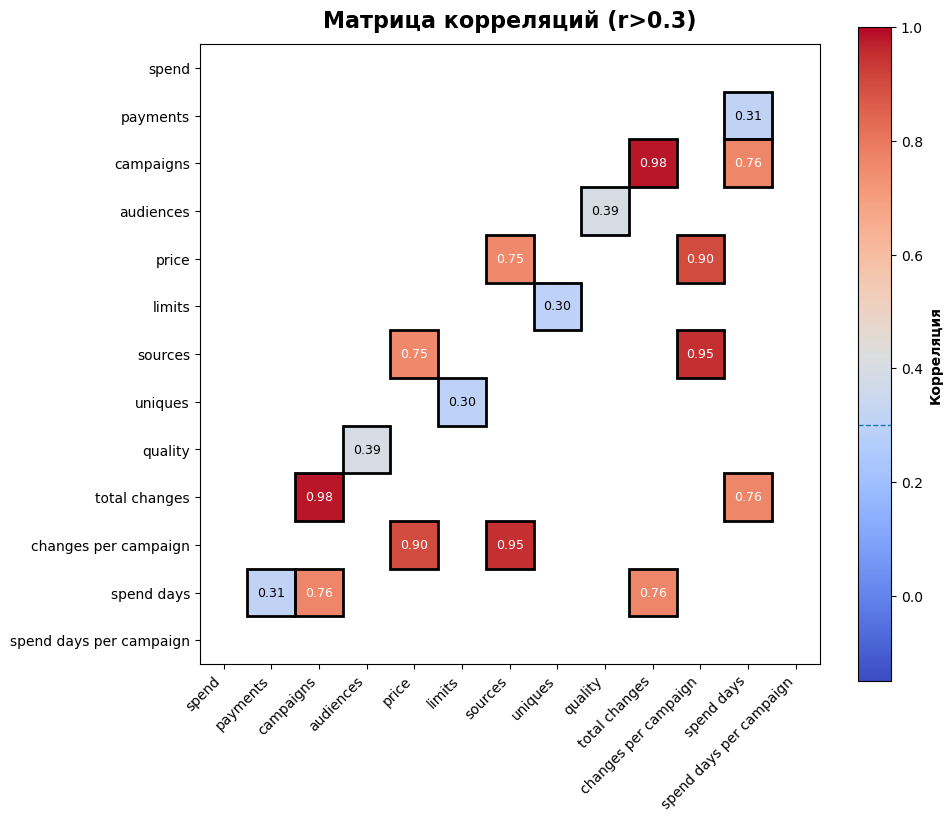

In [125]:
thr = 0.30
vmin, vmax = -0.15, 1.0
figsize = (10, 10)          # <-- задайте свой размер

# оставляем видимыми только > thr (но НИЧЕГО не удаляем из осей)
corr_masked = corr.where(corr > thr)

# убираем диагональ (единицы), чтобы не «забивали» картинку
np.fill_diagonal(corr_masked.values, np.nan)

# подписи: только убрать подчёркивания
def clean_label(s: str) -> str:
    return s.replace("_", " ")

row_labels = [clean_label(s) for s in corr_masked.index]
col_labels = [clean_label(s) for s in corr_masked.columns]

fig, ax = plt.subplots(figsize=figsize)

cmap = plt.cm.coolwarm.copy()
cmap.set_bad(alpha=0.0)   # NaN (<=thr и диагональ) — прозрачные

im = ax.imshow(corr_masked, vmin=vmin, vmax=vmax, cmap=cmap)

ny, nx = corr_masked.shape
ax.set_xticks(np.arange(nx))
ax.set_xticklabels(col_labels, rotation=45, ha='right')
ax.set_yticks(np.arange(ny))
ax.set_yticklabels(row_labels)

# аннотации только для видимых значений
for i in range(ny):
    for j in range(nx):
        val = corr_masked.iat[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}",
                    ha='center', va='center',
                    color='white' if abs(val) > 0.5 else 'black',
                    fontsize=9)

# рамка вокруг ячеек > thr
for i in range(ny):
    for j in range(nx):
        val = corr_masked.iat[i, j]
        if not np.isnan(val) and val > thr:
            ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1,
                                   fill=False, edgecolor='black', linewidth=2))

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("Корреляция", fontweight='bold')
cbar.ax.hlines(thr, *cbar.ax.get_xlim(), linestyles='--', linewidth=1)

ax.set_title("Матрица корреляций (r>0.3)", fontsize=16, fontweight='bold', pad=12)
#plt.tight_layout()
plt.show()

Какие интересные корреляции можно наблюдать:
* quality&audiences $r = ~0.4$ : небольшая положительная линейная зависимость
- - -
* payments&spend days $r = ~0.3$ : неудивительно
- - -
* campaigns&total changes $r = 0.98$ : прямая зависимость, что логично
- - -
* campaigns&spend days $r = ~0.76$ - вполне логично
- - -
* price&changes per campaign $r = 0.9$ - видим высокий коэффициент r, сложно объяснить характер зависимости
<br> Возможно это говорит о том, что большинство юзеров в первую очередь работают с ценой, но это лишь гипотеза
- - -
* sources&changes per campaign $r = 0.95$ : аналогично предыдущему случаю
- - -
* sources&price $r = 0.75$ : для тех, кто работает с сурсами, характерна работа с ценой
- - -
* total changes&spend days $r = 0.76$ : тоже объяснимая зависимость, кто дольше работает - делает больше изменений

<font size="4">Итог
    
Так как для сегментации мы будем использовать модель кластеризации, нам важно исключить мультиколлинеарные признаки.
Почему? Ответ 
<a href="https://clicka.atlassian.net/browse/AN-1837?focusedCommentId=30835">здесь</a>
    
По матрице мы видим, что большинство признаков сильно коррелируют с тремя : total changes, changes per campaign, spend days
<br> Так как для каждого признака у нас есть аналог по смыслу/значению (total changes|campaigns, changes per campaign|является кумулятивной суммой изменений в каждой группе, spend days|spend days per campaign)
    
Удаляем эти признаки для обучения модели

In [129]:
test_data = df.drop(columns = ['email', 'user_id', 'total_changes', 'changes_per_campaign', 'spend_days'])

In [130]:
test_data.head()

,spend,payments,campaigns,audiences,price,limits,sources,uniques,quality,spend_days_per_campaign
0,472.7,3,8,0.25,3.2500,0.0000,0.2500,0.125,0.0,25.6875
1,106759.4,3,7,0.00,0.0000,1.2857,0.0000,0.000,0.0,43.4419
2,1119.8,7,12,1.50,1.8333,0.0000,0.0833,0.000,1.0,2.5833
3,6006.8,1,15,1.80,0.4667,0.0000,1.5333,0.000,0.0,55.6216
4,0.0,0,1,0.00,2.0000,0.0000,1.0000,0.000,0.0,0.0000


Итого у нас осталось 10 целевых признаков, а именно - спенд, кол-во пополнений, кол-во кампаний на юзера, все группы таргетов/настроек (их 6), и кол-во дней со спендом на 1 кампанию. <br><br>Отличный набор признаков для модели

### Кластеризация

#### Определим оптимальное число групп

##### Дендрограмма

Обязательная стандартизация данных перед работой с алгоритмами

In [135]:
sc = StandardScaler()

In [136]:
X_sc = sc.fit_transform(test_data)

Иерархируем данные методом "ward" <a href="https://clicka.atlassian.net/browse/AN-1837?focusedCommentId=30836">(краткое описание метода)</a>

In [138]:
linked = linkage(X_sc, method = 'ward') 

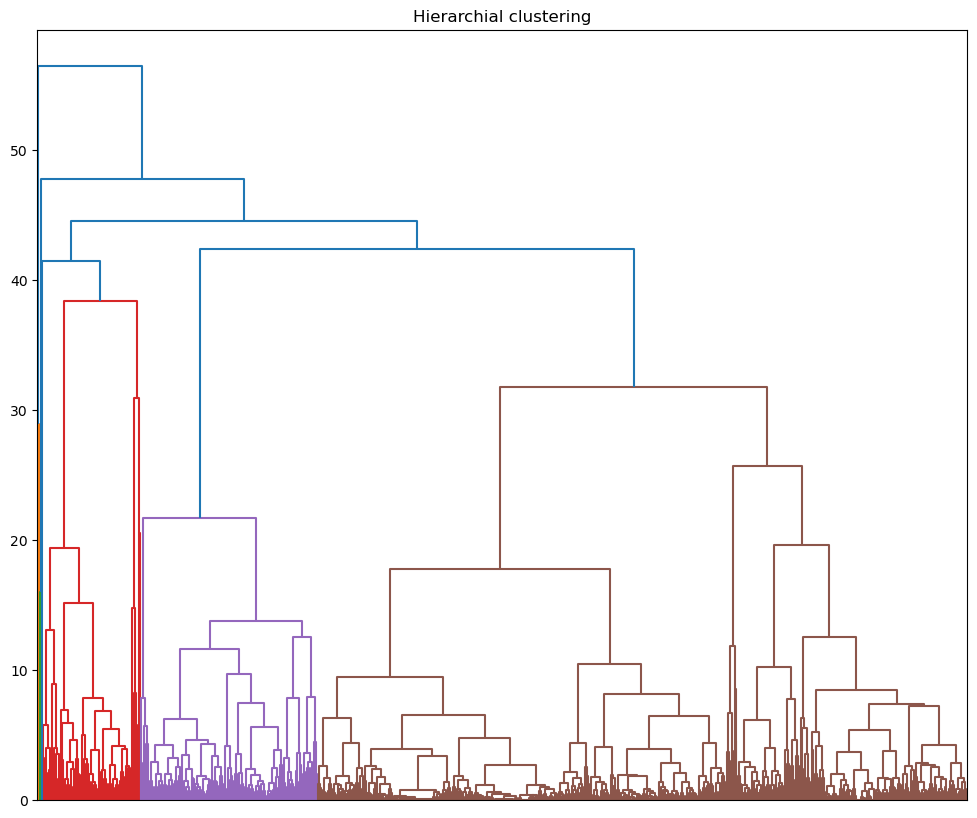

In [272]:
plt.figure(figsize=(12, 10))  
dendrogram(linked, orientation='top', no_labels=True)
plt.title('Hierarchial clustering')
plt.show() 

Видим очень короткую левую группа около 0, затем 3 разноцветных кластера, при этом правый очень большой и хочется его разделить на 2. 
<br>Пока кажется оптимальным кол-вом кластеров - 5, попробуем отрисовать силуэт скор и посмотреть что покажет он

##### Cилуэт-скор

Подробнее о метрике <a href="https://clicka.atlassian.net/browse/AN-1837?focusedCommentId=30837">здесь</a>

In [158]:
def plot_silhouette_ward(X, k_min=2, k_max=20):
    Z = linkage(X, method='ward')  # Ward всегда с евклидой
    ks = np.arange(k_min, k_max + 1)

    sil = []
    for k in ks:
        labels = fcluster(Z, t=k, criterion='maxclust')
        sil.append(silhouette_score(X, labels, metric='euclidean'))
    sil = np.array(sil)

    # "локоть": максимальное отклонение от хорды
    x1, y1 = ks[0], sil[0]
    x2, y2 = ks[-1], sil[-1]
    denom = np.hypot(x2 - x1, y2 - y1) or 1.0
    d = np.abs((y2 - y1) * ks - (x2 - x1) * sil + x2 * y1 - y2 * x1) / denom
    k_elbow = int(ks[np.argmax(d)])
    k_best  = int(ks[np.argmax(sil)])

    plt.figure(figsize=(6, 4))
    plt.plot(ks, sil, marker='o')
    plt.axvline(k_elbow, linestyle='--', label=f'elbow≈{k_elbow}')
    plt.axvline(k_best,  linestyle=':',  label=f'max={k_best}')
    plt.xlabel('k (число кластеров)')
    plt.ylabel('silhouette score')
    plt.title('Silhouette vs k')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return ks, sil, k_elbow, k_best

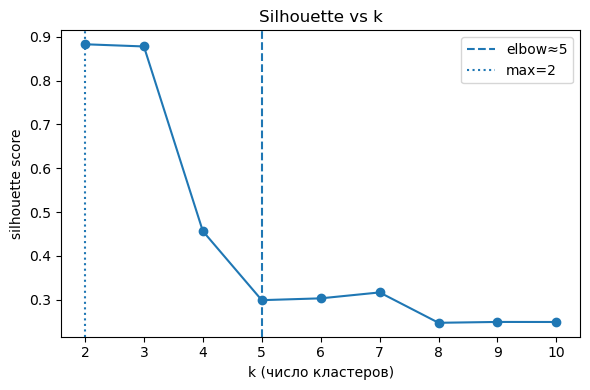

In [162]:
plot_silhouette_ward(X_sc, k_min=2, k_max=10);

Локоть приходится на значение $k = 5$, однако при таких значениях $k$ мы видим низкий силуэт-скор (~0.3).<br>
<br> На начальном этапе этой задачи обеспечим максимальную разделимость между кластерами, выберем $k = 3$ <br>Скор для $k = 2, k = 3$ почти не отличается, поэтому здесь выберем большее значение групп. <br>Для $k =4, k = 5$ видим резкий обвал метрики, что говорит о наименьших различиях в случае данного кол-ва групп <br><br>В случае, если бизнес не устроит данное разделение, скорректируем кол-во групп

#### Обучение модели

In [163]:
km = KMeans(n_clusters=3, random_state=0)

In [164]:
labels = km.fit_predict(X_sc)

Присвоим метки к данным

In [166]:
df['cluster'] = labels

In [168]:
print('Кол-во пользователей в группах')
df['cluster'].value_counts()

Кол-во пользователей в группах


cluster
1    894
0    290
2      1
Name: count, dtype: int64

Видим что на кластер 2 приходится всего 1 пользователь, неужели это Зинченко?

In [170]:
df.query('cluster == 2')

,user_id,email,spend,payments,campaigns,audiences,price,limits,sources,uniques,quality,total_changes,changes_per_campaign,spend_days,spend_days_per_campaign,cluster
184,187186,dbazlov@kudi.studio,868.4,6,22,2.4545,286.0,1.2273,440.4545,0.0,0.0,16063.0,730.1364,986.0,36.5185,2


Это пользователь, который очень много редактирует сурсы и цены, делает это постоянно для всех кампаний

In [173]:
df.query('email.str.contains("zinch")', engine="python")

,user_id,email,spend,payments,campaigns,audiences,price,limits,sources,uniques,quality,total_changes,changes_per_campaign,spend_days,spend_days_per_campaign,cluster
289,37321,zinchenko_elenka@bk.ru,3938.1,5,8981,2.0109,0.1068,0.9998,0.9994,0.9996,0.0,45951.0,5.1165,15000.0,1.6388,0


Кроме кол-во кампаний, остальные метрики у Зинченко не выбиваются из нормы (напомню что сумму изменений и дни спенда мы удалили из признаков для обучения)

В связи с этим удалим только первого юзера и посмотрим как отработает модель. <br>Так как в текущем виде кластеризация неудовлитворительна - не хочется оставлять группу/кластер только из одного юзера

#### Переобучим модель

Подготовим данные

In [202]:
test_data_clean = test_data.drop(184)

Стандартизируем

In [203]:
X_sc_clean = sc.fit_transform(test_data_clean)

Силуэт-скор

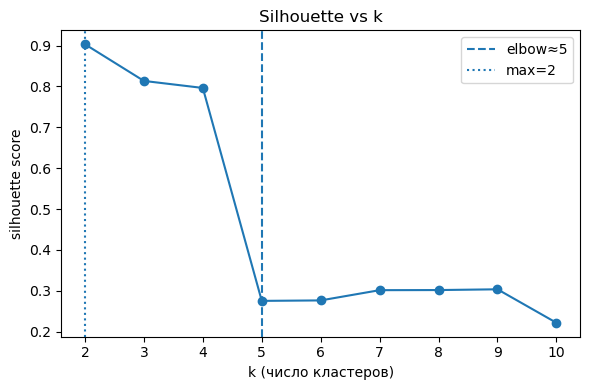

In [204]:
plot_silhouette_ward(X_sc_clean, k_min=2, k_max=10);

Видим что теперь неплохой скор дают 4 группы (~0.8)

Переобучим модель на новых вводных

In [210]:
km_4 = KMeans(n_clusters=4, random_state=0)

In [211]:
labels_clean = km_4.fit_predict(X_sc_clean)

Для правильной склейки из исходного фрейма так же удалим юзера по индексу

In [212]:
df_1 = df.drop(184)

In [213]:
df_1['cluster'] = labels_clean

In [214]:
df_1['cluster'].value_counts()

cluster
3    811
0    269
2    102
1      2
Name: count, dtype: int64

Теперь видим группу из 2х юзеров, к остальным нет претензий по наполненности

Посмотрим что за пользователи попали в эту группу

In [215]:
df_1.query('cluster == 1')

,user_id,email,spend,payments,campaigns,audiences,price,limits,sources,uniques,quality,total_changes,changes_per_campaign,spend_days,spend_days_per_campaign,cluster
289,37321,zinchenko_elenka@bk.ru,3938.1,5,8981,2.0109,0.1068,0.9998,0.9994,0.9996,0.0000,45951.0,5.1165,15000.0,1.6388,1
295,165666,pkonline589@gmail.com,6617.7,65,15953,2.9623,0.0378,1.0034,0.0014,1.0000,0.0001,79844.0,5.0050,20310.0,1.3425,1


Как и ожидалось, это пользователи с огромным кол-вом кампаний. <br>Пожалуй можем добавить сюда юзера из первой итерации, и назвать эту группу аномальной. <br>Остальные кластеры изучим детальнее

In [223]:
df.loc[184, 'cluster'] = 1

In [229]:
df_1 = pd.concat([df_1, df[184:185].reindex(columns=df_1.columns)], ignore_index=True)

In [234]:
df_1[-5:]

,user_id,email,spend,payments,campaigns,audiences,price,limits,sources,uniques,quality,total_changes,changes_per_campaign,spend_days,spend_days_per_campaign,cluster
1180,155157,dalto00@hotmail.com,23.8,1,10,4.2000,0.1,0.8000,0.9000,0.1,0.0,61.0,6.1000,21.0,1.9091,3
1181,168090,runaya2102@gmail.com,56.9,1,2,1.5000,0.0,1.0000,0.0000,0.0,0.0,5.0,2.5000,3.0,1.5000,3
1182,200301,jaaaan988@gmail.com,20.4,1,1,5.0000,0.0,1.0000,0.0000,1.0,0.0,7.0,7.0000,2.0,2.0000,3
1183,200238,mobigudoxu348@gmail.com,66.5,1,1,1.0000,1.0,0.0000,0.0000,0.0,0.0,2.0,2.0000,4.0,1.0000,3
1184,187186,dbazlov@kudi.studio,868.4,6,22,2.4545,286.0,1.2273,440.4545,0.0,0.0,16063.0,730.1364,986.0,36.5185,1


Финальный датасет готов

### Описание групп

#### Группа 1

In [238]:
group1 = df_1.query('cluster == 1')

In [244]:
group1

,user_id,email,spend,payments,campaigns,audiences,price,limits,sources,uniques,quality,total_changes,changes_per_campaign,spend_days,spend_days_per_campaign,cluster
288,37321,zinchenko_elenka@bk.ru,3938.1,5,8981,2.0109,0.1068,0.9998,0.9994,0.9996,0.0000,45951.0,5.1165,15000.0,1.6388,1
294,165666,pkonline589@gmail.com,6617.7,65,15953,2.9623,0.0378,1.0034,0.0014,1.0000,0.0001,79844.0,5.0050,20310.0,1.3425,1
1184,187186,dbazlov@kudi.studio,868.4,6,22,2.4545,286.0000,1.2273,440.4545,0.0000,0.0000,16063.0,730.1364,986.0,36.5185,1


In [242]:
print('Спенд на 1 кампанию для 1 группы')
group1['spend']/group1['campaigns']

Спенд на 1 кампанию для 1 группы


288      0.438492
294      0.414825
1184    39.472727
dtype: float64

Это "аномальная" группа. <br>Здесь всего 3 юзера, 2 из них имеют >8k кампаний


<br>Если характеризовать группу, то можно отметить следующие моменты :
- Очень низкий спенд на 1 кампанию (~0.4$) "для Зинченко и пкОнлайн"
- При этом пополняется "пк" гораздо чаще (в 13 раз), что говорит о мелких пополнениях
- Лимиты и уники испольуются одинаково и практически в каждой кампании
- Цены, как и сурсы, чаще меняет Зинченко
- Кол-во изменений на 1 кампанию схоже для обоих клиентов
- 3 юзер, как было отмечено ранее, аномально часто меняет настройки сурсов и цены (730 изменений на 1 кампанию)
- работа с аудиториями схожа для всех трёх клиентов (от 2 до 3 изменений на кампанию)

#### Группа 0

In [253]:
group0 = df_1.query('cluster == 0')

In [254]:
group0.describe()

,user_id,spend,payments,campaigns,audiences,price,limits,sources,uniques,quality,total_changes,changes_per_campaign,spend_days,spend_days_per_campaign,cluster
count,269.000000,269.000000,269.000000,269.000000,269.000000,269.00000,269.000000,269.000000,269.000000,269.000000,269.000000,269.000000,269.000000,269.000000,269.0
mean,150169.249071,247.086245,1.631970,16.985130,6.019258,2.09691,1.673709,0.843229,0.737563,0.889755,159.104089,12.260425,73.178439,5.454813,0.0
std,65538.120458,625.445646,2.710238,88.147391,3.362040,2.92489,3.085615,2.459771,1.004420,0.587515,715.431383,7.207027,345.377802,8.166249,0.0
min,110.000000,0.000000,0.000000,1.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.0
25%,102603.000000,20.400000,0.000000,1.000000,3.800000,0.33330,0.000000,0.000000,0.000000,0.600000,16.000000,7.581400,3.000000,1.434800,0.0
50%,188415.000000,52.300000,1.000000,3.000000,5.000000,1.03130,1.000000,0.000000,0.750000,1.000000,35.000000,10.470600,10.000000,2.388900,0.0
75%,196203.000000,178.400000,2.000000,10.000000,8.000000,3.00000,2.000000,0.860600,1.000000,1.000000,100.000000,15.000000,37.000000,6.000000,0.0
max,200330.000000,6251.400000,30.000000,1327.000000,22.500000,33.75000,39.000000,27.750000,10.750000,3.000000,10018.000000,63.000000,4552.000000,61.000000,0.0


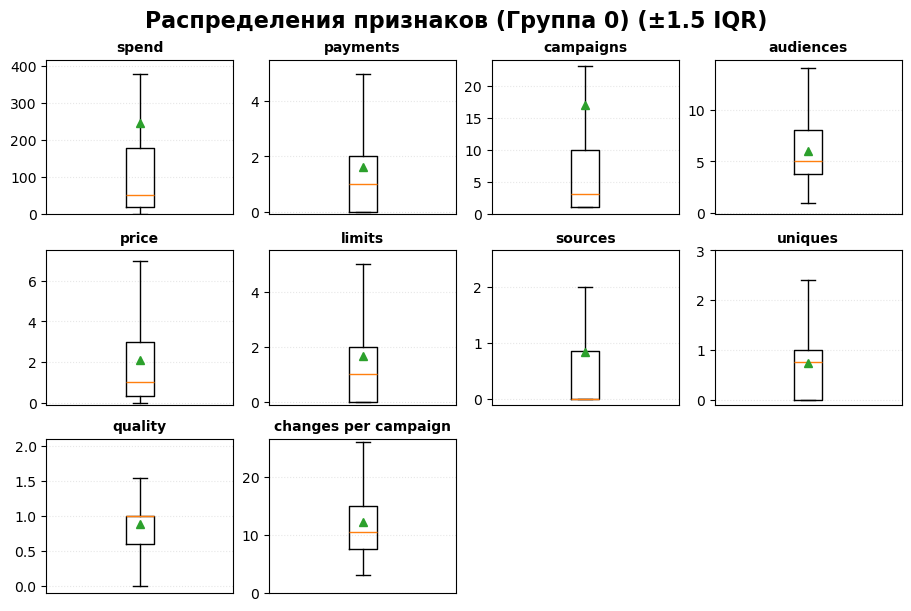

In [258]:
exclude =  {'user_id', 'email', 'spend_days', 'spend_days_per_campaign',
           'total_changes', 'cluster'}
ncols = 4                       # сколько графиков в строке
figsize_per_plot = (4, 3.5)     # размер одного подграфика (дюймы)
show_means = True               # показывать среднее

# очистка названий: убрать все 'g<числа>' и '_'
def clean_label(s: str) -> str:
    s = re.sub(r"g\d+_?", " ", s)   # g1, g23, g7_ и т.п.
    return s.replace("_", " ")      # или .replace("_", " ") — если хотите пробелы

# границы по Тьюки (с защитой для вырожденных случаев)
def tukey_limits(x: np.ndarray):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return None
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    if not np.isfinite(iqr) or iqr == 0:
        if x.size > 1:
            lo, hi = np.percentile(x, [1, 99])
            if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
                lo, hi = x.min(), x.max()
        else:
            m = float(x[0]); lo, hi = m-1, m+1
    else:
        lo = q1 - 1.5 * iqr
        hi = q3 + 1.5 * iqr
    if lo == hi:
        pad = 0.5 if lo == 0 else 0.05 * abs(lo)
        lo -= pad; hi += pad
    return float(lo), float(hi)

# --- выбор колонок
num_cols = group0.select_dtypes(include="number").columns
cols = [c for c in num_cols if c not in exclude]
k = len(cols)
if k == 0:
    raise ValueError("Нет числовых колонок (кроме 'user_id' и 'email') для boxplot.")

# --- фигура и оси
nrows = math.ceil(k / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(9, 6), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

# --- отрисовка
for ax, col in zip(axes, cols):
    x = group0[col].dropna().astype(float).values
    if x.size == 0:
        ax.set_visible(False); continue

    lims = tukey_limits(x)
    if lims is None:
        ax.set_visible(False); continue
    ylo_tukey, yhi = lims

    # нижнюю границу фиксируем на -0.01, верхнюю — как рассчитали по Тьюки
    ylo = -0.1
    if yhi <= ylo:              # страховка на случай вырожденного диапазона
        yhi = ylo + 0.01

    ax.boxplot(
        x,
        vert=True,
        whis=1.5,          # усы = ±1.5 IQR от квартилей
        showfliers=False,  # выбросы не рисуем
        showmeans=show_means,
        meanline=False
    )
    ax.set_ylim(ylo, yhi + 0.5)
    ax.set_title(clean_label(col), fontsize=10, fontweight='bold', pad=6)
    ax.set_xticks([])
    ax.grid(axis='y', linestyle=':', alpha=0.3)

# скрыть пустые ячейки сетки
for ax in axes[k:]:
    ax.set_visible(False)

fig.suptitle("Распределения признаков (Группа 0) (±1.5 IQR)", fontsize=16, fontweight='bold')
plt.show()

В этой группе у нас 269 юзеров, хочется характеризовать её как неопределившихся, неопытных мелких юзеров.. Почему?

Медианный спенд 50 баксов, верхняя граница размаха 400 (среднее значение равно 250, значит это не одноразовые залётчики). 
<br>Пополняются в основном 1 раз (от 1 до 4 раз), создают около 3х кампаний (среднее значение >15, что говорит о некоторых выбросах)
<br>Делают около 10 изменений на одну кампанию, чаще работают с аудиториями, и редко - с сурсами

#### Группа 2

In [262]:
group2 = df_1.query('cluster == 2')

In [263]:
group2.describe()

,user_id,spend,payments,campaigns,audiences,price,limits,sources,uniques,quality,total_changes,changes_per_campaign,spend_days,spend_days_per_campaign,cluster
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.00000,102.000000,102.000000,102.0
mean,110823.323529,4274.633333,11.647059,22.470588,2.225647,5.428210,1.698593,5.618682,0.399018,0.122889,268.833333,15.49304,815.480392,40.064516,2.0
std,68904.901181,11244.529709,17.522629,62.790506,1.796918,17.527626,3.577678,31.823078,0.461785,0.278705,747.717823,40.11165,1877.571719,21.144602,0.0
min,49.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.00000,9.000000,1.670600,2.0
25%,41258.750000,475.950000,1.000000,2.000000,0.200950,0.500000,0.000000,0.000000,0.000000,0.000000,11.250000,4.52500,79.000000,25.143400,2.0
50%,129284.500000,1391.250000,4.000000,4.000000,2.113650,1.840900,0.666700,0.333300,0.250000,0.000000,29.000000,7.18335,186.000000,38.500000,2.0
75%,175244.000000,4587.325000,12.500000,11.750000,3.766675,4.950000,1.761000,1.446425,0.666700,0.026250,127.000000,11.58555,532.000000,57.000000,2.0
max,197423.000000,106759.400000,90.000000,401.000000,6.000000,171.428600,23.200000,308.000000,2.000000,1.273700,5290.000000,330.50000,11510.000000,79.000000,2.0


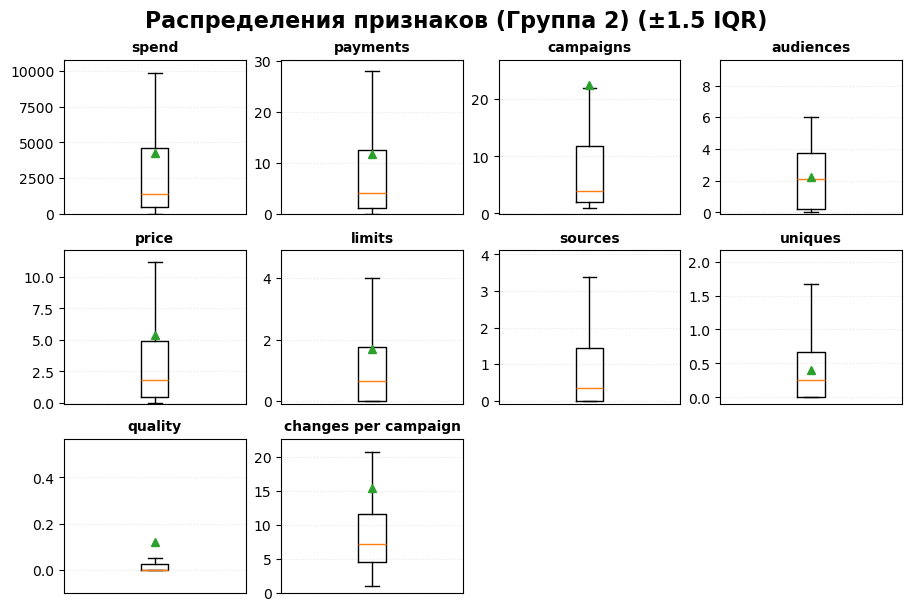

In [264]:
exclude =  {'user_id', 'email', 'spend_days', 'spend_days_per_campaign',
           'total_changes', 'cluster'}
ncols = 4                       # сколько графиков в строке
figsize_per_plot = (4, 3.5)     # размер одного подграфика (дюймы)
show_means = True               # показывать среднее

# очистка названий: убрать все 'g<числа>' и '_'
def clean_label(s: str) -> str:
    s = re.sub(r"g\d+_?", " ", s)   # g1, g23, g7_ и т.п.
    return s.replace("_", " ")      # или .replace("_", " ") — если хотите пробелы

# границы по Тьюки (с защитой для вырожденных случаев)
def tukey_limits(x: np.ndarray):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return None
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    if not np.isfinite(iqr) or iqr == 0:
        if x.size > 1:
            lo, hi = np.percentile(x, [1, 99])
            if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
                lo, hi = x.min(), x.max()
        else:
            m = float(x[0]); lo, hi = m-1, m+1
    else:
        lo = q1 - 1.5 * iqr
        hi = q3 + 1.5 * iqr
    if lo == hi:
        pad = 0.5 if lo == 0 else 0.05 * abs(lo)
        lo -= pad; hi += pad
    return float(lo), float(hi)

# --- выбор колонок
num_cols = group0.select_dtypes(include="number").columns
cols = [c for c in num_cols if c not in exclude]
k = len(cols)
if k == 0:
    raise ValueError("Нет числовых колонок (кроме 'user_id' и 'email') для boxplot.")

# --- фигура и оси
nrows = math.ceil(k / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(9, 6), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

# --- отрисовка
for ax, col in zip(axes, cols):
    x = group2[col].dropna().astype(float).values
    if x.size == 0:
        ax.set_visible(False); continue

    lims = tukey_limits(x)
    if lims is None:
        ax.set_visible(False); continue
    ylo_tukey, yhi = lims

    # нижнюю границу фиксируем на -0.01, верхнюю — как рассчитали по Тьюки
    ylo = -0.1
    if yhi <= ylo:              # страховка на случай вырожденного диапазона
        yhi = ylo + 0.01

    ax.boxplot(
        x,
        vert=True,
        whis=1.5,          # усы = ±1.5 IQR от квартилей
        showfliers=False,  # выбросы не рисуем
        showmeans=show_means,
        meanline=False
    )
    ax.set_ylim(ylo, yhi + 0.5)
    ax.set_title(clean_label(col), fontsize=10, fontweight='bold', pad=6)
    ax.set_xticks([])
    ax.grid(axis='y', linestyle=':', alpha=0.3)

# скрыть пустые ячейки сетки
for ax in axes[k:]:
    ax.set_visible(False)

fig.suptitle("Распределения признаков (Группа 2) (±1.5 IQR)", fontsize=16, fontweight='bold')
plt.show()

Группа 2 это "жирные" пользователи, которые знают, что им нужно (всего 102 клиента)
<br>Медианный спенд более 1000 долларов, средний - приближается к 5000. <br>Пополняются в среднем 10 раз, медиана - 4 (значит крупные пополнения). <br>В среднем имеют 20 кампаний, медиана - 4, довольно большой разброс. <br> Очень точечно работают с аудиторией - в среднем 2 изменения на кампанию, активно используют цену как инструмент. <br>Так же пользуются лимитами, реже - сурсами, униками и настройками качества

#### Группа 3

In [267]:
group3 = df_1.query('cluster == 3')

In [268]:
group3.describe()

,user_id,spend,payments,campaigns,audiences,price,limits,sources,uniques,quality,total_changes,changes_per_campaign,spend_days,spend_days_per_campaign,cluster
count,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.0
mean,145461.183724,224.237855,0.981504,9.658446,3.020382,1.137274,0.827787,0.372754,0.293931,0.033883,66.928483,5.686013,48.923551,4.589603,3.0
std,65679.685088,687.077328,1.899552,49.462099,1.816344,1.743250,1.122834,1.831899,0.438058,0.117360,392.018190,3.932006,226.242679,6.346854,0.0
min,115.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,3.0
25%,94073.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,3.000000,0.000000,0.000000,3.0
50%,182704.000000,38.400000,1.000000,2.000000,3.000000,0.555600,0.500000,0.000000,0.000000,0.000000,11.000000,5.088200,5.000000,2.000000,3.0
75%,195434.000000,120.100000,1.000000,5.000000,4.000000,1.563500,1.250000,0.055700,0.563500,0.000000,32.000000,7.444400,27.000000,6.000000,3.0
max,200439.000000,8048.200000,20.000000,808.000000,10.000000,16.000000,11.000000,41.000000,2.000000,1.000000,6805.000000,57.500000,3817.000000,36.000000,3.0


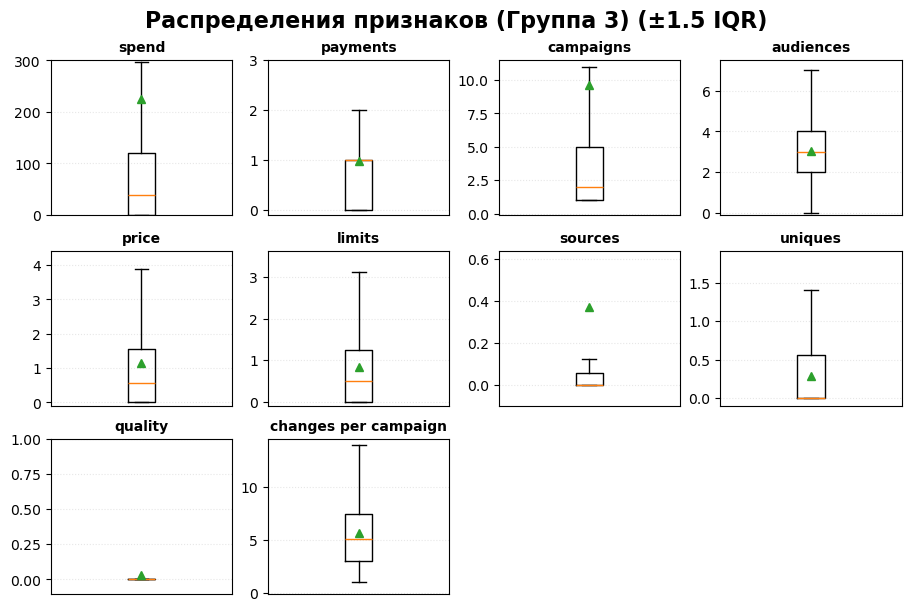

In [271]:
exclude =  {'user_id', 'email', 'spend_days', 'spend_days_per_campaign',
           'total_changes', 'cluster'}
ncols = 4                       # сколько графиков в строке
figsize_per_plot = (4, 3.5)     # размер одного подграфика (дюймы)
show_means = True               # показывать среднее

# очистка названий: убрать все 'g<числа>' и '_'
def clean_label(s: str) -> str:
    s = re.sub(r"g\d+_?", " ", s)   # g1, g23, g7_ и т.п.
    return s.replace("_", " ")      # или .replace("_", " ") — если хотите пробелы

# границы по Тьюки (с защитой для вырожденных случаев)
def tukey_limits(x: np.ndarray):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return None
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    if not np.isfinite(iqr) or iqr == 0:
        if x.size > 1:
            lo, hi = np.percentile(x, [1, 99])
            if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
                lo, hi = x.min(), x.max()
        else:
            m = float(x[0]); lo, hi = m-1, m+1
    else:
        lo = q1 - 1.5 * iqr
        hi = q3 + 1.5 * iqr
    if lo == hi:
        pad = 0.5 if lo == 0 else 0.05 * abs(lo)
        lo -= pad; hi += pad
    return float(lo), float(hi)

# --- выбор колонок
num_cols = group3.select_dtypes(include="number").columns
cols = [c for c in num_cols if c not in exclude]
k = len(cols)
if k == 0:
    raise ValueError("Нет числовых колонок (кроме 'user_id' и 'email') для boxplot.")

# --- фигура и оси
nrows = math.ceil(k / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(9, 6), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

# --- отрисовка
for ax, col in zip(axes, cols):
    x = group3[col].dropna().astype(float).values
    if x.size == 0:
        ax.set_visible(False); continue

    lims = tukey_limits(x)
    if lims is None:
        ax.set_visible(False); continue
    ylo_tukey, yhi = lims

    # нижнюю границу фиксируем на -0.01, верхнюю — как рассчитали по Тьюки
    ylo = -0.1
    if yhi <= ylo:              # страховка на случай вырожденного диапазона
        yhi = ylo + 0.01

    ax.boxplot(
        x,
        vert=True,
        whis=1.5,          # усы = ±1.5 IQR от квартилей
        showfliers=False,  # выбросы не рисуем
        showmeans=show_means,
        meanline=False
    )
    ax.set_ylim(ylo, yhi + 0.5)
    ax.set_title(clean_label(col), fontsize=10, fontweight='bold', pad=6)
    ax.set_xticks([])
    ax.grid(axis='y', linestyle=':', alpha=0.3)

# скрыть пустые ячейки сетки
for ax in axes[k:]:
    ax.set_visible(False)

fig.suptitle("Распределения признаков (Группа 3) (±1.5 IQR)", fontsize=16, fontweight='bold')
plt.show()

Самая многочисленная (811) и следовательно самая разнородная группа клиентов, немного напоминает группу 0. <br>Отметим ключевые отличия, чтобы затем изучить и разграничить схожие признаки между двумя группами

Отличительные особенности группы :
- качество и сурсы по нулям, аудитории и уники используются реже группы 0
- медиана изменений на кампанию - 5 раз (в два раза ниже группы 0, что говорит о большей пассивности данной группы)
- меньшее кол-во пополнений и используемых кампаний

В целом можно охарактеризовать эту группу как более пассивную, остальные признаки кажется схожи с группой 0, рассмотрим их детальнее

#### Сравнительный анализ схожих признаков группы 0 и 3

##### Спенд

###### Распределение признака в группах

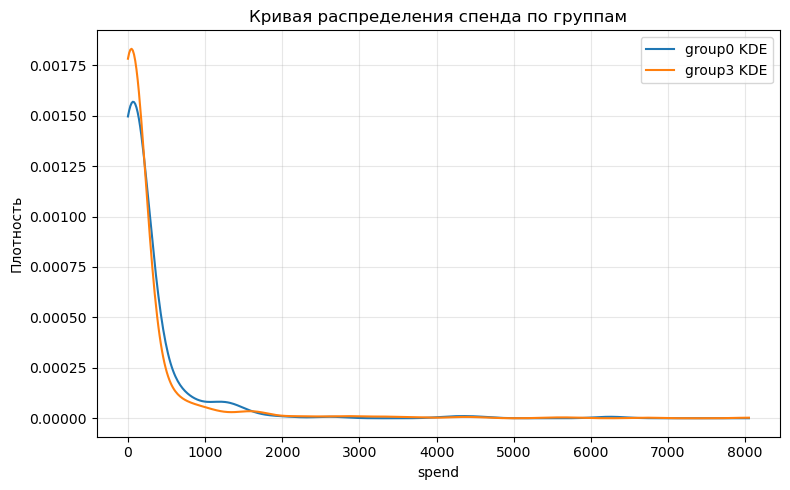

In [336]:
x0 = group0['spend'].dropna().to_numpy()
x3 = group3['spend'].dropna().to_numpy()

# Общая сетка по всему диапазону значений
xmin = min(x0.min(), x3.min())
xmax = max(x0.max(), x3.max())
grid = np.linspace(xmin, xmax, 512)

# KDE — возьмём правило Скотта; при желании можно подстроить ширину: bw_method=0.5 (меньше — острее)
kde0 = gaussian_kde(x0, bw_method='scott')
kde3 = gaussian_kde(x3, bw_method='scott')

y0 = kde0(grid)
y3 = kde3(grid)

plt.figure(figsize=(8,5))
plt.plot(grid, y0, label='group0 KDE')
plt.plot(grid, y3, label='group3 KDE')
plt.xlabel('spend')
plt.ylabel('Плотность')
plt.title('Кривая распределения спенда по группам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


KDE (kernel density estimate) — это сглаженная оценка плотности распределения. Это как «гистограмма с бесконечно тонкими бинами»: кривая показывает, где значения встречаются чаще/реже, но высота — это плотность, а не «кол-во наблюдений». Площадь под кривой = 1.

По кривым плотности не видим большой разницы в распределении признака между группами

###### t-Критерий Стьюдента

Функция для t-Теста + Стандартное отклонение ($SD$) + Коэффициент вариации ($CV = SD/|mean|$)

In [315]:
def student_t_test(a, b, confidence=0.95, alternative='two-sided'):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[~np.isnan(a)];       b = b[~np.isnan(b)]
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        raise ValueError("В каждой группе должно быть >= 2 наблюдений.")

    mean_a, mean_b = a.mean(), b.mean()
    sd_a   = a.std(ddof=1);    sd_b   = b.std(ddof=1)
    cv_a   = sd_a / abs(mean_a) if mean_a != 0 else np.nan
    cv_b   = sd_b / abs(mean_b) if mean_b != 0 else np.nan

    # ДИ по средним групп
    tcrit_a = stats.t.ppf((1 + confidence) / 2, n1 - 1)
    tcrit_b = stats.t.ppf((1 + confidence) / 2, n2 - 1)
    ci_a = (mean_a - tcrit_a * stats.sem(a), mean_a + tcrit_a * stats.sem(a))
    ci_b = (mean_b - tcrit_b * stats.sem(b), mean_b + tcrit_b * stats.sem(b))

    # классический t-тест (равные дисперсии)
    df = n1 + n2 - 2
    sp2 = ((n1 - 1) * sd_a**2 + (n2 - 1) * sd_b**2) / df
    se_diff = np.sqrt(sp2 * (1/n1 + 1/n2))
    t_stat = (mean_a - mean_b) / se_diff
    if alternative == 'two-sided':
        p_value = 2 * stats.t.sf(abs(t_stat), df)
    elif alternative == 'greater':
        p_value = stats.t.sf(t_stat, df)
    elif alternative == 'less':
        p_value = stats.t.cdf(t_stat, df)
    else:
        raise ValueError("alternative: 'two-sided' | 'greater' | 'less'")

    tcrit = stats.t.ppf((1 + confidence) / 2, df)
    diff = mean_a - mean_b
    ci_diff = (diff - tcrit * se_diff, diff + tcrit * se_diff)

    return {
        "n_A": n1, "mean_A": mean_a, "sd_A": sd_a, "cv_A": cv_a, "ci_A": ci_a,
        "n_B": n2, "mean_B": mean_b, "sd_B": sd_b, "cv_B": cv_b, "ci_B": ci_b,
        "mean_diff": diff, "ci_diff": ci_diff,
        "t_stat": t_stat, "df": df, "p_value": p_value,
        "confidence": confidence, "alternative": alternative
    }

Проверка

In [316]:
res_t = student_t_test(group0['spend'], group3['spend'])

In [323]:
print(f"Group 0: mean={res_t['mean_A']:.1f}, SD={round(res_t['sd_A'])}, CV={round(res_t['cv_A']*100)}%, "
      f"95% CI=({res_t['ci_A'][0]:.1f}, {res_t['ci_A'][1]:.1f}), n={res_t['n_A']}")
print(f"Group 3: mean={res_t['mean_B']:.1f}, SD={round(res_t['sd_B'])}, CV={round(res_t['cv_B']*100)}%, "
      f"95% CI=({res_t['ci_B'][0]:.1f}, {res_t['ci_B'][1]:.1f}), n={res_t['n_B']}")
print(f"Diff : {res_t['mean_diff']:.1f}; "
      f"t({round(res_t['df'])})={res_t['t_stat']:.3f}, p={res_t['p_value']:.3g}")

Group 0: mean=247.1, SD=625, CV=253%, 95% CI=(172.0, 322.2), n=269
Group 3: mean=224.2, SD=687, CV=306%, 95% CI=(176.9, 271.6), n=811
Diff : 22.8; t(1078)=0.483, p=0.629


Cтатистически значимых различий нет (t(1078)=0.483, p=0.629). <br>Текущие данные не дают оснований считать, что средние A и B различаются.

На что обратить внимание:

Тест — классический Стьюдента с предположением равенства дисперсий. У нас отношение дисперсий ≈ 1.21 (391k vs 472k) — не критично, но при заметно неравных размерах групп (269 vs 811) полезно для проверки также глянуть Welch t-test как устойчивую альтернативу.

**Подробности теста**

Дисперсии очень большие по сравнению со средними, значит разброс в группах огромный и, скорее всего, распределения сильно «растянуты»/скошены или есть выбросы.

Что это значит в цифрах

Стандартные отклонения (корень из дисперсии):
A ≈ 625, B ≈ 687 (в тех же единицах, что и метрика).

Относительный разброс (коэффициент вариации = SD/mean):
A ≈ 253%, B ≈ 306% — это очень много: разброс в несколько раз больше среднего.

Соотношение дисперсий: B/A ≈ 1.21 — различаются умеренно. Для классического t-теста это не катастрофа, но помнить о неравных объёмах (269 vs 811) всё равно стоит.

«Сигнал/шум»: разница средних 22.85 при «общем» SD порядка ≈672 и стандартной ошибке разницы ≈47.3. Отсюда и t=0.483, p=0.629: на фоне такого шума разница крошечная.

Как трактовать


Такой высокий CV обычно указывает на сильную асимметрию/тяжёлые хвосты или смешение разных подгрупп (например, разная аудитория/каналы).

Большая дисперсия резко снижает мощность теста: даже заметные в бизнесе смещения становятся статистически неуловимыми, пока вы не увеличите n или не уменьшите разброс.

###### t-Критерий Уэлша

Функция

In [298]:
def welch_t_test(a, b, confidence=0.95, alternative='two-sided'):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[~np.isnan(a)];       b = b[~np.isnan(b)]
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        raise ValueError("В каждой группе должно быть >= 2 наблюдений.")

    mean_a, mean_b = a.mean(), b.mean()
    sd_a, sd_b = a.std(ddof=1), b.std(ddof=1)
    cv_a = sd_a / abs(mean_a) if mean_a != 0 else np.nan
    cv_b = sd_b / abs(mean_b) if mean_b != 0 else np.nan

    # SE и df по Welch–Satterthwaite
    se_diff = np.sqrt(sd_a**2 / n1 + sd_b**2 / n2)
    df = (sd_a**2 / n1 + sd_b**2 / n2)**2 / (
        (sd_a**4) / (n1**2 * (n1 - 1)) + (sd_b**4) / (n2**2 * (n2 - 1))
    )

    t_stat = (mean_a - mean_b) / se_diff
    if alternative == 'two-sided':
        p_value = 2 * stats.t.sf(abs(t_stat), df)
        tcrit = stats.t.ppf((1 + confidence) / 2, df)
    elif alternative == 'greater':  # H1: A > B
        p_value = stats.t.sf(t_stat, df)
        tcrit = stats.t.ppf(confidence, df)
    elif alternative == 'less':     # H1: A < B
        p_value = stats.t.cdf(t_stat, df)
        tcrit = stats.t.ppf(confidence, df)
    else:
        raise ValueError("alternative: 'two-sided' | 'greater' | 'less'")

    diff = mean_a - mean_b
    ci_diff = (diff - tcrit * se_diff, diff + tcrit * se_diff)

    # ДИ по средним групп (обычные t-интервалы с df=n-1)
    tcrit_a = stats.t.ppf((1 + confidence) / 2, n1 - 1)
    tcrit_b = stats.t.ppf((1 + confidence) / 2, n2 - 1)
    ci_a = (mean_a - tcrit_a * stats.sem(a), mean_a + tcrit_a * stats.sem(a))
    ci_b = (mean_b - tcrit_b * stats.sem(b), mean_b + tcrit_b * stats.sem(b))

    return {
        "n_A": n1, "mean_A": mean_a, "sd_A": sd_a, "cv_A": cv_a, "ci_A": ci_a,
        "n_B": n2, "mean_B": mean_b, "sd_B": sd_b, "cv_B": cv_b, "ci_B": ci_b,
        "mean_diff": diff, "ci_diff": ci_diff,
        "t_stat": t_stat, "df": df, "p_value": p_value,
        "confidence": confidence, "alternative": alternative,
        "test": "Welch t-test"
    }

Проверка

In [319]:
res_w = welch_t_test(group0['spend'], group3['spend'])

In [320]:
print(f"Welch t({round(res_w['df'])})={res_w['t_stat']:.3f}, p={res_w['p_value']:.4g}")

Welch t(499)=0.506, p=0.6128


В чём отличие Welch от классического t-теста

Student (equal var) предполагает равенство дисперсий двух групп и использует пулённую дисперсию 

Welch не требует равных дисперсий: использует SE и df по формуле Уэлча–Саттертуэйта (обычно меньше, чем у Student)

Надёжность. При неравных дисперсиях/размерах Welch лучше контролирует ошибку I рода; Student может «ложно» находить значимость, особенно если у группы с большей дисперсией меньше наблюдений.

Точность/мощность. Welch не обязательно «консервативнее». В нашем кейсе (n сильно неравны: 269 vs 811, дисперсии отличаются на ~21%), Welch даёт меньшую SE, несмотря на меньшие df.

Видим только меньшее кол-во степеней свободы (df), p-value для критерия Уэлша практически идентичен

###### Итог 
Не видим стат значимых различий по спенду между группой 0 (активные пользователи) и группой 3 (пассивные)

##### Активность

Попробуем потвердить/опровергнуть гипотезу о различии в активности групп 0 и 3

In [322]:
res_t_activity = student_t_test(group0['changes_per_campaign'], group3['changes_per_campaign'])

In [328]:
print(f"Group 0: mean={res_t_activity['mean_A']:.1f}, SD={round(res_t_activity['sd_A'])}, CV={round(res_t_activity['cv_A']*100)}%, "
      f"95% CI=({res_t_activity['ci_A'][0]:.1f}, {res_t_activity['ci_A'][1]:.1f}), n={res_t_activity['n_A']}")
print(f"Group 3: mean={res_t_activity['mean_B']:.1f}, SD={round(res_t_activity['sd_B'])}, CV={round(res_t_activity['cv_B']*100)}%, "
      f"95% CI=({res_t_activity['ci_B'][0]:.1f}, {res_t_activity['ci_B'][1]:.1f}), n={res_t_activity['n_B']}")
print(f"Diff : {res_t_activity['mean_diff']:.1f}; "
      f"t({round(res_t_activity['df'])})={res_t_activity['t_stat']:.3f}, p={res_t_activity['p_value']:.3g}")

Group 0: mean=12.3, SD=7, CV=59%, 95% CI=(11.4, 13.1), n=269
Group 3: mean=5.7, SD=4, CV=69%, 95% CI=(5.4, 6.0), n=811
Diff : 6.6; t(1078)=18.866, p=7.94e-69


Видим двукратную разницу средних, довольно узкие и непересекающиеся доверительные интервалы.
<br>Высокое значение t-статистики и крайне низкое p-value, что даёт нам полное основание отвергнуть $H0$ о равенстве средних

Так же данные нам дают основания говорить о том, что группа 0 ведёт себя активнее

### Резюме

Мы разделили наших пользователей на 4 группы, коротко их можно охарактеризовать так :

1 группа - аномальная, в ней всего 3 юзера. <br>Двое из них создают аномальное кол-во кампаний, один делает аномальное кол-во изменений

Группа 0 - 22% (269 клиентов) 
<br> Эту группу можно охарактеризовать как активных клиентов с небольшим в среднем спендом. Они эксперементируют с кампаниями и настройками и ищут оптимальные связки

Группа 2 - 8% юзеров (102 клиента)
<br> Это "жирные" клиенты, которые точечно используют настройки с пониманием их ценности

Группа 3 - 68% (811 клиентов)
<br> Самая многочисленная группа. Это пассивная группа, которая не так активно эксперементирует с настройками и кампаниями как группа 0, при этом по спенду эта группа не сильно отличается от нулевой

Группы очень четко разделены по целевым признакам.
<br>
Так как признаков очень много и у них одинаковый удельный вес, в текущей модели кластеризации допустимо смешение групп
<br>
При необходимости (расстановке акцентов от бизнеса) модель можно доработать